In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Loading the datasets and the libraries required

In [2]:
import os
import re
import glob
import pandas as pd

data_root = "/kaggle/input/datasets/tejasreddy/iam-handwriting-top50"
img_dir = os.path.join(data_root, "data_subset", "data_subset")
meta_path = os.path.join(data_root, "forms_for_parsing.txt")

# sanity check
print("Images found:", len(glob.glob(img_dir + "/*.png")))
print("Metadata exists:", os.path.exists(meta_path))

Images found: 4899
Metadata exists: True


# Build the labelled dataframe 

In [3]:
# load metadata
meta = pd.read_csv(meta_path, sep=" ", header=None)
meta = meta.iloc[:, :2]
meta.columns = ["form_id", "writer_id"]

# extract form_id from each image filename
def get_form_id(filename):
    match = re.match(r"^(.*)-s\d{2}-\d{2}\.png$", filename)
    return match.group(1) if match else None

all_files = glob.glob(img_dir + "/*.png")

df = pd.DataFrame({"path": all_files})
df["filename"] = df["path"].apply(os.path.basename)
df["form_id"] = df["filename"].apply(get_form_id)

# merge in writer labels
df = df.merge(meta, on="form_id", how="left")

# drop the one unmapped row 
df = df.dropna(subset=["writer_id"]).reset_index(drop=True)
df["writer_id"] = df["writer_id"].astype(int).astype(str)

print(df.shape)
df.head()

(4898, 4)


,path,filename,form_id,writer_id
0,/kaggle/input/datasets/tejasreddy/iam-handwrit...,b06-093-s01-05.png,b06-093,125
1,/kaggle/input/datasets/tejasreddy/iam-handwrit...,c03-087c-s01-00.png,c03-087c,152
2,/kaggle/input/datasets/tejasreddy/iam-handwrit...,c03-084c-s00-02.png,c03-084c,152
3,/kaggle/input/datasets/tejasreddy/iam-handwrit...,c06-087-s00-04.png,c06-087,126
4,/kaggle/input/datasets/tejasreddy/iam-handwrit...,h06-003-s02-02.png,h06-003,349


# Check class balance across the 50 writers

count     50.000000
mean      97.960000
std       89.228887
min       45.000000
25%       64.000000
50%       86.500000
75%      104.000000
max      692.000000
Name: count, dtype: float64


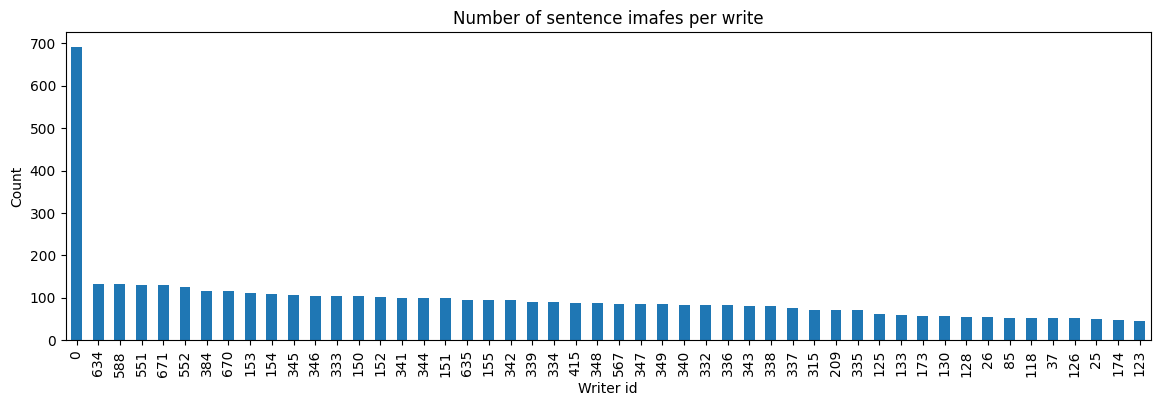

In [4]:
counts = df["writer_id"].value_counts()
print(counts.describe())

import matplotlib.pyplot as plt
counts.plot(kind="bar",figsize=(14,4))
plt.title("Number of sentence imafes per write")
plt.xlabel("Writer id")
plt.ylabel("Count")
plt.show()

# Train Test Split

In [5]:
from sklearn.model_selection import train_test_split
train_df,test_df = train_test_split(
    df,
    test_size =0.2,
    stratify=df["writer_id"],
    random_state = 42
)
print("Train:",train_df.shape)
print("Test:",test_df.shape)
print("Writers in train:",train_df["writer_id"].nunique())
print("Writers in test:",test_df["writer_id"].nunique())

Train: (3918, 4)
Test: (980, 4)
Writers in train: 50
Writers in test: 50


# Preprocerss and visualize 

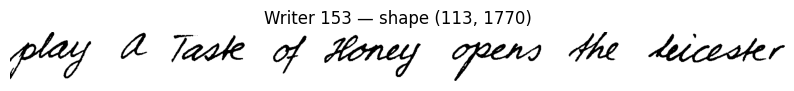

In [6]:
import cv2
import matplotlib.pyplot as plt

def preprocess(path, target_height=113):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    scale = target_height / h
    img = cv2.resize(img, (int(w * scale), target_height))
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return img

sample_row = train_df.iloc[0]
img = preprocess(sample_row["path"])

plt.figure(figsize=(10, 3))
plt.imshow(img, cmap="gray")
plt.title(f"Writer {sample_row['writer_id']} — shape {img.shape}")
plt.axis("off")
plt.show()

# Patch extraction

Number of patches from this image: 30


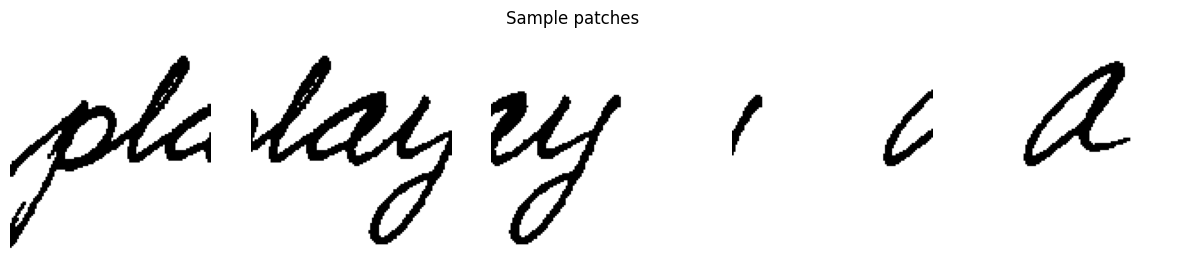

In [7]:
import numpy as np

def extract_patches(img, patch_size=113, stride=56):
    patches = []
    h, w = img.shape
    if w < patch_size:
        img = cv2.copyMakeBorder(img, 0, 0, 0, patch_size - w, cv2.BORDER_CONSTANT, value=255)
        w = patch_size
    for x in range(0, w - patch_size + 1, stride):
        patch = img[:, x:x + patch_size]
        patches.append(patch)
    return patches

# test on our sample image
patches = extract_patches(img)
print(f"Number of patches from this image: {len(patches)}")

fig, axes = plt.subplots(1, min(5, len(patches)), figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(patches[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Sample patches")
plt.show()

# Step 7: Build the full patch dataset (train and test)

In [8]:
def build_patch_dataset(dataframe):
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = preprocess(row["path"])
        img_patches = extract_patches(img)
        X.extend(img_patches)
        y.extend([row["writer_id"]] * len(img_patches))
    return np.array(X), np.array(y)

X_train, y_train = build_patch_dataset(train_df)
print("Train patches:", X_train.shape, y_train.shape)

Train patches: (94732, 113, 113) (94732,)


In [9]:
print("Unique writers in train patches:", len(np.unique(y_train)))

Unique writers in train patches: 50


In [10]:
X_test, y_test = build_patch_dataset(test_df)
print("Test patches:", X_test.shape, y_test.shape)
print("Unique writers in test patches:", len(np.unique(y_test)))

Test patches: (23810, 113, 113) (23810,)
Unique writers in test patches: 50


# Encode labels and normalize pixel values

In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
print("Num classes:", num_classes)

y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# normalize and add channel dimension for CNN input
X_train_norm = X_train[..., np.newaxis].astype("float32") / 255.0
X_test_norm = X_test[..., np.newaxis].astype("float32") / 255.0

print("X_train_norm shape:", X_train_norm.shape)
print("X_test_norm shape:", X_test_norm.shape)

Num classes: 50
X_train_norm shape: (94732, 113, 113, 1)
X_test_norm shape: (23810, 113, 113, 1)


# Compute class weights

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights))

print("Min weight:", min(class_weight_dict.values()))
print("Max weight:", max(class_weight_dict.values()))

Min weight: 0.09262931455949937
Max weight: 2.9836850393700787


# Build the CNN architecture

In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(113, 113, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1785730292.504380      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785730292.508454      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 111, 111, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 53, 53, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,824,370 (18.40 MB)

 Trainable params: 4,824,370 (18.40 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Train the model

In [15]:
history = model.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_test_norm, y_test_cat),
    epochs=15,
    batch_size=128,
    class_weight=class_weight_dict
)

Epoch 1/15
  3/741 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.0030 - loss: 4.2686      

I0000 00:00:1785730327.038868     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


741/741 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.3438 - loss: 2.4987 - val_accuracy: 0.5178 - val_loss: 1.6495
Epoch 2/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.5376 - loss: 1.6672 - val_accuracy: 0.6123 - val_loss: 1.3435
Epoch 3/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.6180 - loss: 1.3349 - val_accuracy: 0.6658 - val_loss: 1.1479
Epoch 4/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.6654 - loss: 1.1070 - val_accuracy: 0.6580 - val_loss: 1.1374
Epoch 5/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.7071 - loss: 0.9215 - val_accuracy: 0.6837 - val_loss: 1.0977
Epoch 6/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.7438 - loss: 0.7737 - val_accuracy: 0.6614 - val_loss: 1.1627
Epoch 7/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.7703 - loss: 0.6594 - val_accuracy: 0.6700 - val_loss: 1.1838
Epoch 8/15
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.7954 - loss: 0.5731 - val_accurac

In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    layers.Input(shape=(113, 113, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),   # new block — shrinks feature map further
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),        # reduced from 256
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 111, 111, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 53, 53, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,434 (2.50 MB)

 Trainable params: 656,434 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_test_norm, y_test_cat),
    epochs=25,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - accuracy: 0.2929 - loss: 2.7009 - val_accuracy: 0.4896 - val_loss: 1.7442
Epoch 2/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.4923 - loss: 1.8682 - val_accuracy: 0.5969 - val_loss: 1.3777
Epoch 3/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.5558 - loss: 1.5985 - val_accuracy: 0.6503 - val_loss: 1.2108
Epoch 4/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.6016 - loss: 1.4068 - val_accuracy: 0.6652 - val_loss: 1.1167
Epoch 5/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.6320 - loss: 1.2688 - val_accuracy: 0.6796 - val_loss: 1.0846
Epoch 6/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.6595 - loss: 1.1574 - val_accuracy: 0.7015 - val_loss: 1.0180
Epoch 7/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.6789 - loss: 1.0653 - val_accuracy: 0.6977 - val_loss: 1.0204
Epoch 8/25
741/741 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.6964 - loss: 0.9805 - 

# Evaluate patch-level accuracy

In [18]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat)
print(f"Patch-level test accuracy: {test_acc:.4f}")
print(f"Patch-level test loss: {test_loss:.4f}")

745/745 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7231 - loss: 0.9486
Patch-level test accuracy: 0.7231
Patch-level test loss: 0.9486


In [19]:
from collections import Counter

def predict_sentence(path, model, le):
    img = preprocess(path)
    patches = extract_patches(img)
    patches = np.array(patches)[..., np.newaxis].astype("float32") / 255.0
    preds = model.predict(patches, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    majority_class = Counter(pred_classes).most_common(1)[0][0]
    return le.inverse_transform([majority_class])[0]

correct = 0
for _, row in test_df.iterrows():
    pred = predict_sentence(row["path"], model, le)
    correct += (pred == row["writer_id"])

sentence_acc = correct / len(test_df)
print(f"Sentence-level accuracy: {sentence_acc:.4f}")

Sentence-level accuracy: 0.9153


In [20]:
model.save("/kaggle/working/writer_id_model.keras")

In [21]:
import pickle
with open("/kaggle/working/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)